## Initial baseline model

In [1]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.preprocess import *
from scripts.pt_model import *
from scripts.basic_model import *

In [2]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")
print(ground_truth_df.columns)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth'],
      dtype='str')


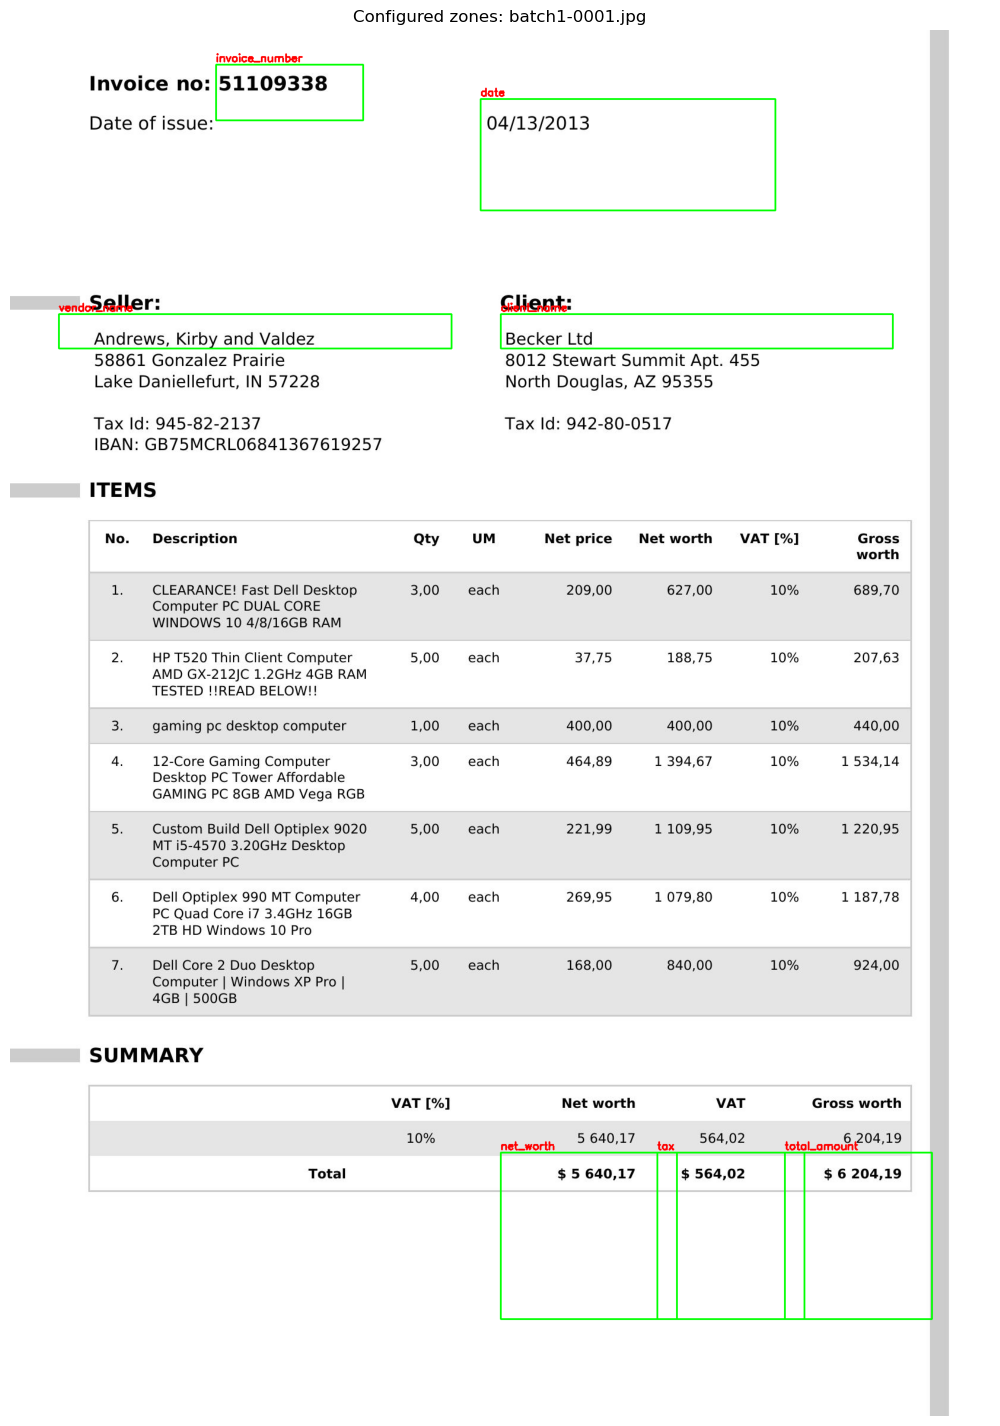

{'invoice_number': '51109338', 'date': '04/13/2013', 'vendor_name': 'Andrews, Kirby and Valdez', 'client_name': 'Becker Ltd', 'net_worth': '5640.17', 'tax': '564.02', 'total_amount': '6204.19'}
{'invoice_number': '51109338', 'date': '04/13/2013', 'vendor_name': 'Andrews, Kirby and Valdez', 'client_name': 'Becker Ltd', 'net_worth': '$5640,17', 'tax': '$564,02', 'total_amount': '$6204,19'}


In [3]:
zones = {
        "default": {
        # Top-left: Invoice number
        "invoice_number": (0.21, 0.025, 0.15, 0.04),

        # Slightly below, shifted right: Date
        "date": (0.48, 0.05, 0.30, 0.08),

        # Middle section
        "vendor_name": (0.05, 0.205, 0.40, 0.025),   # Seller block
        "client_name": (0.50, 0.205, 0.40, 0.025),   # Client block

        # Bottom-right summary section
        "net_worth": (0.50, 0.81, 0.18, 0.12),      # Net worth
        "tax": (0.66, 0.81, 0.15, 0.12),           # VAT
        "total_amount": (0.79, 0.81, 0.15, 0.12),  # Gross worth
        }
        }

# 1) Create the pipeline
basic_pipeline = InvoiceZonalOCRPipeline(template_zones=zones,
    output_dir="../finalproject_data/output_images/basic_ocr"
)

# 2) Tune zones visually on one representative invoice
sample_image = "../finalproject_data/batch_1/batch1_1/batch1-0001.jpg"
basic_pipeline.visualize_zones(sample_image, template_name="default")

# 3) Process one invoice
result = basic_pipeline.process_invoice(sample_image, template_name="default")
print(result["fields"])
print(result["zone_text"])


In [4]:
# 4) Batch process a folder of invoice images
# Define the subfolders you want to process
subfolders = ["batch1_1", "batch1_2", "batch1_3"]
base_path = "../finalproject_data/batch_1/"

# Process each folder and store the resulting dataframes in a list
all_preds = [
    basic_pipeline.process_folder(f"{base_path}{folder}", template_name="default", sample_frac=0.2) 
    for folder in subfolders
]

# Concatenate all dataframes into one
pred_df = pd.concat(all_preds, ignore_index=True)
print(pred_df.head())

Processing 99 images...


Processing invoices: 100%|██████████| 99/99 [03:26<00:00,  2.08s/it]


Processing 100 images...


Processing invoices: 100%|██████████| 100/100 [03:41<00:00,  2.22s/it]


Processing 97 images...


Processing invoices: 100%|██████████| 97/97 [03:34<00:00,  2.22s/it]

         File Name                                         image_path  \
0  batch1-0328.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
1  batch1-0058.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
2  batch1-0013.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
3  batch1-0380.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   
4  batch1-0141.jpg  ../finalproject_data/batch_1/batch1_1/batch1-0...   

   success invoice_number        date              vendor_name  \
0     True       14165207  02/13/2014               Patel-Park   
1     True       80489404  12/21/2013             Gonzalez LLC   
2     True       57986024  10/17/2015              Schmidt LLC   
3     True       13310164  01/16/2020           Montgomery LLC   
4     True       73783721  10/22/2011  Wood, Nichols and Perry   

                  client_name net_worth  tax total_amount  
0  Adkins, Hodges and Hawkins       NaN  NaN          NaN  
1                  Nelson PLC       NaN  NaN

In [5]:
metrics_df = basic_pipeline.evaluate_against_ground_truth(pred_df, ground_truth_df)

         field  accuracy  precision   recall       f1  support
   client_name  0.996390   0.996390 0.996390 0.996390      277
invoice_number  1.000000   1.000000 1.000000 1.000000      277
           tax  0.093863   1.000000 0.093863 0.171617      277
  total_amount  0.086643   0.800000 0.086643 0.156352      277
     net_worth  0.075812   0.913043 0.075812 0.140000      277


In [ ]:
basic_pipeline.visualize_evaluation_metrics(metrics_df)

## CV Model


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [00:46<00:00,  4.65s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:40<00:00,  4.45s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [00:54<00:00,  5.49s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


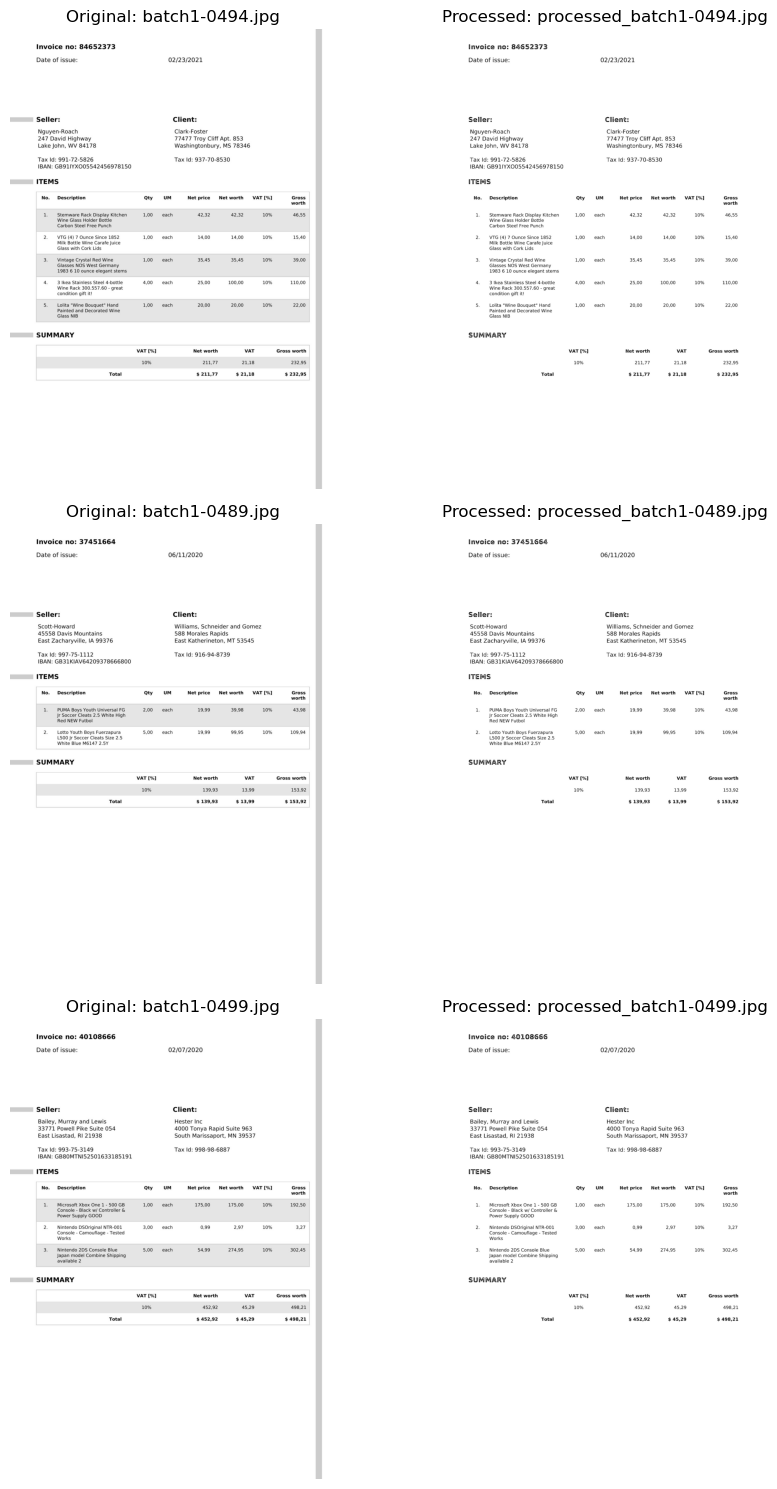

Processed images saved to: ../finalproject_data/processed_images


In [6]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [7]:
# Merge DFs to get processed image file paths
gt_merged_df = pd.merge(ground_truth_df, combined_results, left_on="File Name", right_on="original_file")
print(gt_merged_df.columns)
gt_merged_df.drop(columns=["File Name", "due_date"], inplace=True)

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth', 'original_file', 'processed_file', 'original_path',
       'processed_path', 'status'],
      dtype='str')


In [8]:
# Initialize text detector
ocr_text_detector = PytesseractInvoiceTextDetector(output_dir="../finalproject_data/output_images")

summary_df = ocr_text_detector.process_dataset(combined_results, sample_frac=0.1)

Processing 141 sampled images (10.0%)...


Processing OCR batches: 100%|██████████| 15/15 [02:17<00:00,  9.14s/it]


TEXT DETECTION SUMMARY
Total images processed: 141
Successful extractions: 141
Failed extractions: 0
Average words per image: 139.2
Average confidence: 93.7%

Extracted invoice fields:
  invoice_number: 141 images (100.0%)
  invoice_date: 141 images (100.0%)
  seller_name: 141 images (100.0%)
  client_name: 141 images (100.0%)
  tax: 120 images (85.1%)
  net_worth: 112 images (79.4%)
  total_amount: 120 images (85.1%)


In [9]:
metrics_df, overall = ocr_text_detector.evaluate_against_ground_truth(gt_merged_df)

print(metrics_df)
print("\nOverall:", overall)

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1414
Ground truth unique keys: 1413
Key overlap: 141
            field  ground_truth_count  predicted_count  correct  accuracy  \
0  invoice_number                 141              141      140  0.992908   
1    invoice_date                 141              141      141  1.000000   
2     seller_name                 141              141      141  1.000000   
3     client_name                 141              141      141  1.000000   
4       net_worth                 141              112      108  0.765957   
5    total_amount                 141              120      111  0.787234   
6             tax                 141              120      118  0.836879   

   precision    recall        f1  
0   0.992908  0.992908  0.992908  
1   1.000000  1.000000  1.000000  
2   1.000000  1.000000  1.000000  
3   1.000000  1.000000  1.000000  
4   0.964286  0.765957  0.853755  
5   0.925000  0.787234  0.850575  
6   0.983333  0.8

In [ ]:
ocr_text_detector.debug_end_to_end(combined_results, gt_merged_df, n_samples=5)

Debugging 5 invoices

DEBUGGING FILE: processed_batch1-0858.jpg

OCR WORDS (204 words):
Invoice              | conf= 84 | bbox=(273, 155, 260, 51)
no:                  | conf= 96 | bbox=(567, 167, 106, 39)
59506452             | conf= 94 | bbox=(708, 155, 359, 51)
Date                 | conf= 96 | bbox=(273, 293, 138, 44)
of                   | conf= 96 | bbox=(437, 291, 57, 46)
issue:               | conf= 96 | bbox=(517, 291, 166, 46)
11/20/2017           | conf= 96 | bbox=(1613, 291, 340, 52)
Seller:              | conf= 96 | bbox=(271, 891, 234, 70)
Client:              | conf= 93 | bbox=(1657, 895, 236, 50)
Alexander,           | conf= 95 | bbox=(285, 1021, 294, 48)
Schneider            | conf= 95 | bbox=(605, 1021, 275, 42)
and                  | conf= 96 | bbox=(901, 1021, 96, 42)
Russo                | conf= 96 | bbox=(1025, 1023, 156, 40)
Graham-Martinez      | conf= 91 | bbox=(1673, 1021, 479, 42)
189                  | conf= 96 | bbox=(290, 1094, 97, 41)
Pearson             


Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 141
Successful extractions: 141 (100.0%)
Failed extractions: 0 (0.0%)

OCR QUALITY METRICS
Average words per invoice: 139.2
Median words per invoice: 135
Word count range: 71 - 226
Average OCR confidence: 93.7%
Median OCR confidence: 93.8%
Confidence range: 91.2% - 94.7%

FIELD EXTRACTION SUCCESS RATES
  invoice_number : 100.0%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            :  85.1%
  net_worth      :  79.4%
  total_amount   :  85.1%

FIELD-LEVEL EXACT MATCH ACCURACIES
  invoice_number :  99.3%
  invoice_date   : 100.0%
  seller_name    : 100.0%
  client_name    : 100.0%
  tax            :  83.7%
  net_worth      :  76.6%
  total_amount   :  78.7%


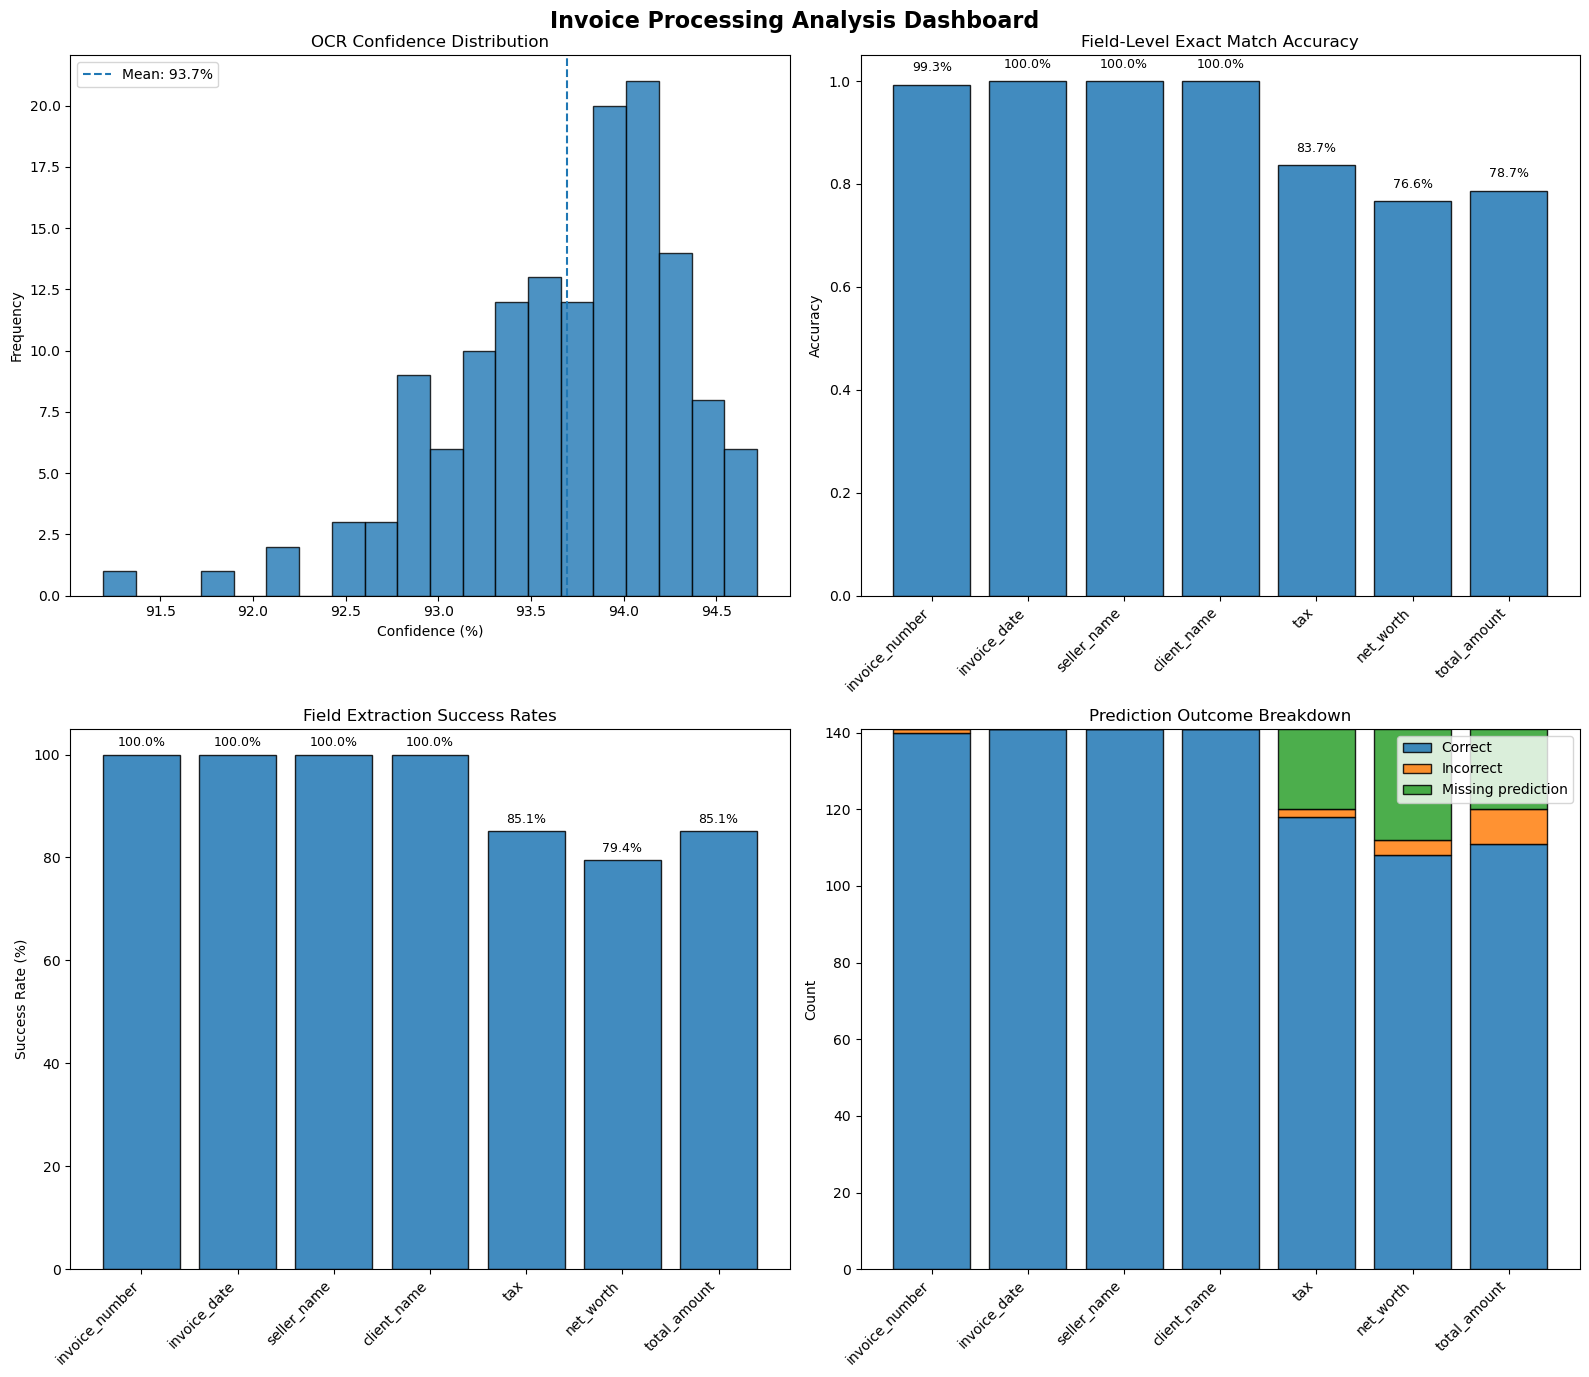


Sample 1: processed_batch1-0858.jpg
Total words detected: 204
Average confidence: 93.4%

Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample extracted text (first 10 words):
  Invoice no: 59506452 Date of issue: 11/20/2017 Seller: Client: Alexander,...


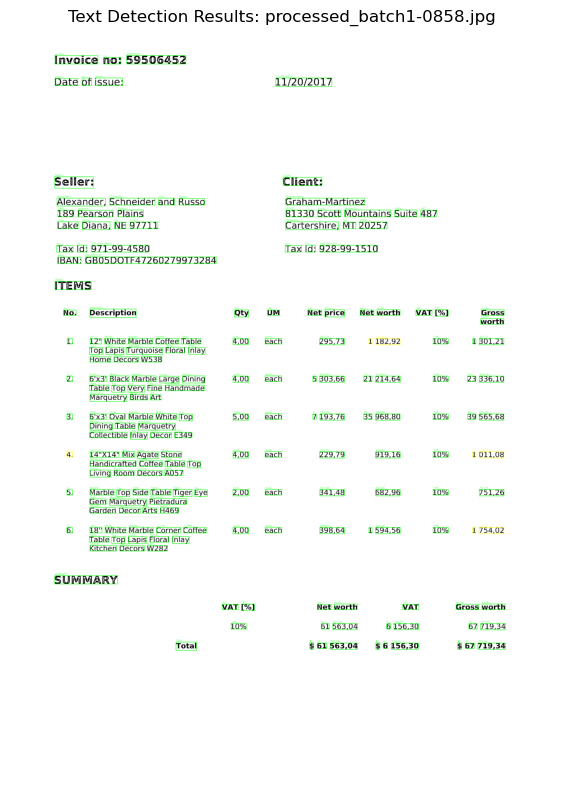


Extracted Invoice Fields:
  invoice_number: 59506452
  invoice_date: 2017-11-20
  seller_name: Alexander, Schneider and Russo
  client_name: Graham-Martinez
  tax: 6156.30
  net_worth: 61563.04
  total_amount: 67719.34

Sample 2: processed_batch1-0935.jpg
Total words detected: 124
Average confidence: 94.4%

Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample extracted text (first 10 words):
  Invoice no: 90172850 Date of issue: 09/22/2012 Seller: Client: Johnson,...


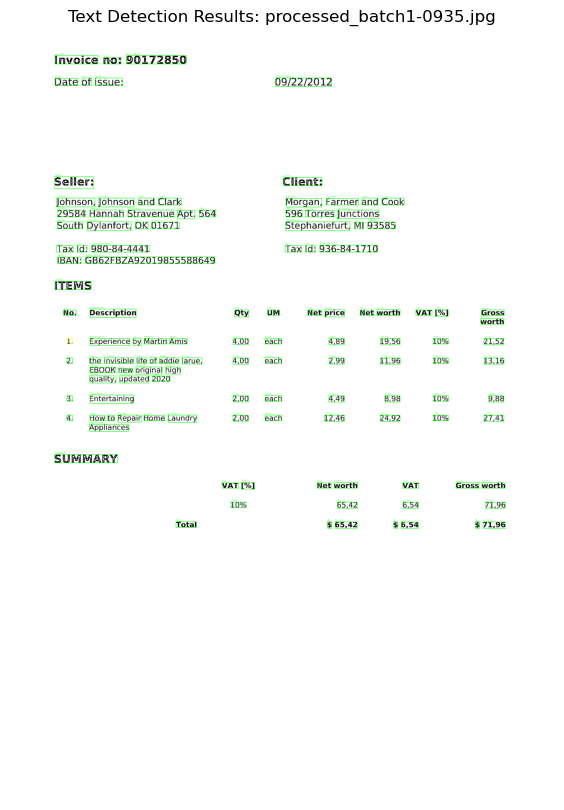


Extracted Invoice Fields:
  invoice_number: 90172850
  invoice_date: 2012-09-22
  seller_name: Johnson, Johnson and Clark
  client_name: Morgan, Farmer and Cook
  tax: 6.54
  net_worth: 65.42
  total_amount: 71.96

Sample 3: processed_batch1-0412.jpg
Total words detected: 116
Average confidence: 93.1%

Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86

Sample extracted text (first 10 words):
  Invoice no: 60866416 Date of issue: 02/17/2021 Seller: Client: Parker,...


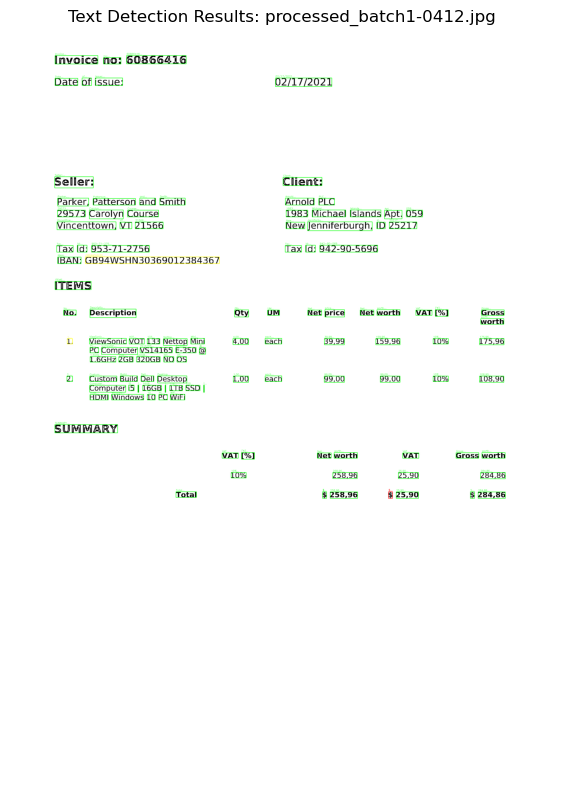


Extracted Invoice Fields:
  invoice_number: 60866416
  invoice_date: 2021-02-17
  seller_name: Parker, Patterson and Smith
  client_name: Arnold PLC
  tax: 25.90
  net_worth: 258.96
  total_amount: 284.86


In [10]:
dashboard_stats = create_analysis_dashboard(
    ocr_text_detector.full_results,
    metrics_df=metrics_df,
    fields=["invoice_number", "invoice_date", "seller_name", "client_name", "tax", "net_worth", "total_amount"]
)

visualize_sample_results(
    ocr_text_detector.full_results,
    visualize_text_fn=ocr_text_detector.visualize_text_extraction,
    n_samples=3
)

## Transformer model (in-development)

In [ ]:
from scripts.donut_model import *

donut_detector = DonutInvoiceTextDetector(
    output_dir="../finalproject_data/donut_output"
)

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

In [ ]:
# Run Donut pipeline
summary_df = donut_detector.process_dataset(
    combined_results,
    sample_frac=0.1,   # optional sampling
    batch_size=4       # Donut is GPU-heavy, keep small
)

print(summary_df.head())

Processing 141 sampled images (10.0%)...
RAW DONUT SEQUENCE: no: 5950452 se se se se se se se se se se se se se se se se se se se se se se se se se se a d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d 
PARSED PAYLOAD: {'text_sequence': 'no: 5950452 se se se se se se se se se se se se se se se se se se se se se se se se se se a d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d d

In [ ]:
ground_truth_df = pd.read_csv("../finalproject_data/cleaned_invoices.csv")

# If needed, create the merge key separately without merging prediction columns in
ground_truth_df["processed_file"] = ground_truth_df["File Name"].apply(lambda x: f"processed_{Path(x).stem}.jpg")

donut_metrics_df, donut_overall = donut_detector.evaluate_against_ground_truth(ground_truth_df)

print(metrics_df)
print("\nOverall Metrics:", overall)

Prediction rows: 141
Prediction unique keys: 141
Ground truth rows: 1413
Ground truth unique keys: 1413
Key overlap: 141
Merged columns: ['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name', 'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount', 'net_worth', 'processed_file']


ValueError: No fields were evaluated. Check that ground_truth_df contains the expected label columns: invoice_number, invoice_date, seller_name, client_name, net_worth, total_amount, tax.

In [ ]:
ground_truth_df.columns

Index(['File Name', 'OCRed Text', 'batch_csv', 'client_name', 'seller_name',
       'invoice_number', 'invoice_date', 'due_date', 'tax', 'total_amount',
       'net_worth', 'processed_file'],
      dtype='str')


Invoice Processing Analysis Dashboard

PROCESSING OVERVIEW
Total images processed: 141
Successful extractions: 141 (100.0%)
Failed extractions: 0 (0.0%)

FIELD EXTRACTION SUCCESS RATES
  invoice_number :   0.0%
  invoice_date   :   0.0%
  seller_name    :   0.0%
  client_name    :   0.0%
  tax            :   0.0%
  net_worth      :   0.0%
  total_amount   :   0.0%


ValueError: autodetected range of [nan, nan] is not finite

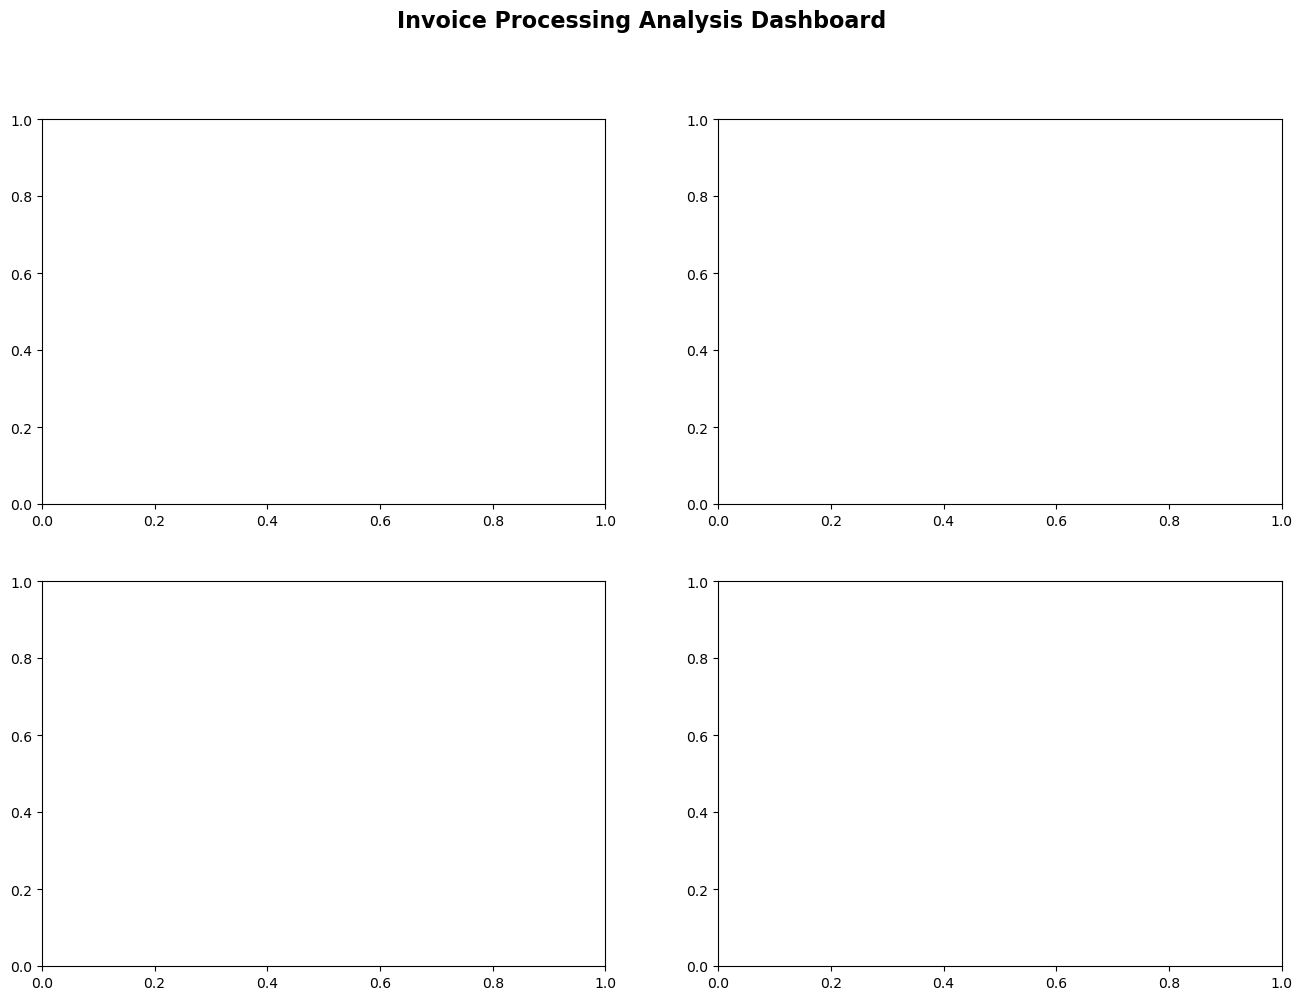

In [ ]:
dashboard_stats = create_analysis_dashboard(
    donut_detector.full_results,
    metrics_df=metrics_df,
    fields=[
        "invoice_number",
        "invoice_date",
        "seller_name",
        "client_name",
        "tax",
        "net_worth",
        "total_amount"
    ]
)

In [ ]:
visualize_sample_results(
    donut_detector.full_results,
    visualize_text_fn=None,   # Donut doesn’t use bounding boxes
    n_samples=3
)